## Decision Tree - Data Preparation

## Step 1: Load and Explore the Data
We begin by loading the cleaned diabetes dataset using pandas. Initial exploration includes checking:
- Shape and sample records.
- Missing values.
- Data types.

This helps us understand the structure before moving on to model preparation.

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('diabetes_cleaned.csv')

# Quick look at the data
print("Dataset Shape:", df.shape)
print("\nSample Rows:")
print(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (70000, 34)

Sample Rows:
                             Target Genetic Markers Autoantibodies  \
0          Steroid-Induced Diabetes        Positive       Negative   
1  Neonatal Diabetes Mellitus (NDM)        Positive       Negative   
2                       Prediabetic        Positive       Positive   
3                   Type 1 Diabetes        Negative       Positive   
4                  Wolfram Syndrome        Negative       Negative   

  Family History Environmental Factors  Insulin Levels  Age   BMI  \
0             No               Present            40.0   44  38.0   
1             No               Present            13.0   10  17.0   
2            Yes               Present            27.0   36  24.0   
3             No               Present             8.0   10  16.0   
4            Yes               Present            17.0   10  17.0   

  Physical Activity Dietary Habits  ...  Pulmonary Function  \
0              High        Healthy  ...                  76 

## Step 2: Encode Categorical Features
Decision Trees handle both numerical and categorical features, but scikit-learn requires categorical data to be encoded.
We use Label Encoding to convert text labels into numeric values.

In [3]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Apply label encoding to object (categorical) columns
label_encoders = {}
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print("Encoded Columns:", list(label_encoders.keys()))

df_encoded.to_csv('dt_prepared.csv', index=False)
print("Encoded and saved as 'dt_prepared.csv'")
print(df_encoded.head(100))

Encoded Columns: ['Target', 'Genetic Markers', 'Autoantibodies', 'Family History', 'Environmental Factors', 'Physical Activity', 'Dietary Habits', 'Ethnicity', 'Socioeconomic Factors', 'Smoking Status', 'Alcohol Consumption', 'Glucose Tolerance Test', 'History of PCOS', 'Previous Gestational Diabetes', 'Pregnancy History', 'Cystic Fibrosis Diagnosis', 'Steroid Use History', 'Genetic Testing', 'Liver Function Tests', 'Urine Test', 'Early Onset Symptoms']
Encoded and saved as 'dt_prepared.csv'
    Target  Genetic Markers  Autoantibodies  Family History  \
0        7                1               0               0   
1        4                1               0               0   
2        5                1               1               1   
3        8                0               1               0   
4       12                0               0               1   
..     ...              ...             ...             ...   
95       4                1               1               0   

## Step 3: Define Features (X) and Target (y)
We split the dataset into:
- X: All independent features (used for prediction)
- y: Target variable (used for classification)

For this project, the target is the presence or absence of diabetes.

In [4]:
# Define features and target
X = df_encoded.drop('Target', axis=1)
y = df_encoded['Target']

## Step 4: Train-Test Split
We divide the dataset into training and testing sets to evaluate the Decision Tree's performance.
We use 80% for training and 20% for testing.

In [5]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 56000
Testing Samples: 14000


In [ ]:
# Combine features and target labels for better visualization
dt_train_preview = X_train.copy()
dt_train_preview["Target"] = y_train

dt_test_preview = X_test.copy()
dt_test_preview["Target"] = y_test

# Display top 5 rows
print("Decision Tree - Training Set Preview:")
display(dt_train_preview.head(100))

print("Decision Tree - Testing Set Preview:")
display(dt_test_preview.head(100))

# Optional: Save preview samples
dt_train_preview.head(100).to_csv("decisiontree_train_sample.csv", index=False)
dt_test_preview.head(100).to_csv("decisiontree_test_sample.csv", index=False)


Decision Tree - Training Set Preview:


,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,Blood Pressure,...,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms,Target
47339,0,1,0,0,12.0,52,31.0,1,0,126,...,1,0,1,2,0,43,1,2765,1,2
67456,0,1,1,1,48.0,68,34.0,2,1,149,...,1,0,1,2,0,43,2,2901,1,6
12308,1,0,1,1,37.0,51,34.0,2,1,108,...,0,0,1,1,1,51,1,3825,1,2
32557,1,0,1,0,27.0,19,22.0,2,0,107,...,1,0,0,1,0,52,2,2707,1,3
664,0,1,0,0,18.0,23,18.0,0,1,119,...,0,1,0,2,0,67,0,3220,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22814,1,1,0,0,47.0,68,27.0,0,0,136,...,0,0,1,3,0,69,3,2841,1,9
15742,0,0,0,0,20.0,63,38.0,2,0,134,...,1,0,1,3,0,46,1,3292,1,7
14104,1,1,1,1,20.0,17,26.0,1,1,105,...,1,1,0,1,1,46,3,2854,0,0
41655,1,1,1,0,48.0,53,28.0,1,0,115,...,0,1,0,2,1,62,0,4297,1,7


Decision Tree - Testing Set Preview:


,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,Blood Pressure,...,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms,Target
46730,0,1,0,1,34.0,54,32.0,2,1,119,...,0,0,0,2,0,63,1,2533,0,6
48393,1,1,0,0,43.0,74,32.0,1,0,123,...,1,1,0,2,0,57,2,2634,1,9
41416,0,1,0,1,20.0,57,27.0,1,1,116,...,0,0,1,3,0,42,1,3947,1,7
34506,0,1,1,0,17.0,30,39.0,0,1,122,...,0,1,1,3,1,91,3,3237,1,9
43725,1,1,0,0,15.0,28,21.0,0,0,103,...,1,0,0,1,0,55,0,2634,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20958,0,1,1,1,17.0,12,24.0,1,0,105,...,0,0,1,2,0,16,0,2692,1,11
57200,0,0,1,1,22.0,33,23.0,2,0,105,...,1,1,0,1,1,42,3,3632,1,2
46957,0,0,0,1,19.0,17,16.0,0,0,87,...,1,0,1,2,1,11,0,1815,1,12
58163,1,1,0,1,34.0,57,28.0,1,1,111,...,1,0,1,2,0,68,0,3548,1,2


: 

## Step 5: Train Decision Trees with Different Root Nodes

We explore how using different root features influences the structure and predictions of Decision Trees. Instead of only changing parameters, we vary the starting point (root node) by prioritizing top features.


## Step 5.1: Train a Base Tree and Identify Top Features

- Train a default Decision Tree using Gini impurity.
- Extract feature importances from the model.
- Identify the top 3 most important features.
- These top features will be used to guide the root node in subsequent trees.

In [15]:
from sklearn.tree import DecisionTreeClassifier

# Train base Decision Tree
base_tree = DecisionTreeClassifier(random_state=42)
base_tree.fit(X_train, y_train)

# Extract top 3 important features
importances = base_tree.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(3)['Feature'].tolist()

print("Top 3 Important Features:", top_features)


Top 3 Important Features: ['Blood Glucose Levels', 'Weight Gain During Pregnancy', 'Age']


## Step 5.2: Reorder Features to Influence Root Node

- Rearrange the feature columns so that each top feature appears first.
- Reordering influences the Decision Tree's root node selection.
- This technique doesn’t guarantee the root but increases its likelihood of being chosen.


In [16]:
# Reorder dataset to move selected feature to first position
def reorder_features(df, root_feature):
    cols = df.columns.tolist()
    cols.remove(root_feature)
    return df[[root_feature] + cols]

# Example preview
reordered = reorder_features(X_train, top_features[0])
print("Reordered columns (example):", reordered.columns.tolist()[:5])


Reordered columns (example): ['Blood Glucose Levels', 'Genetic Markers', 'Autoantibodies', 'Family History', 'Environmental Factors']


## Step 5.3: Train Decision Trees for Each Root Node

- For each of the top 3 features, train a new Decision Tree.
- Use Gini criterion and a fixed random state for reproducibility.
- Keep max depth limited (e.g., 5) to improve interpretability.

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

trees = {}
for feature in top_features:
    X_train_reordered = reorder_features(X_train, feature)
    X_test_reordered = reorder_features(X_test, feature)

    clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
    clf.fit(X_train_reordered, y_train)
    
    trees[feature] = {
        'model': clf,
        'X_test': X_test_reordered
    }

    print(f"Model trained with '{feature}' as the first feature.")


Model trained with 'Blood Glucose Levels' as the first feature.
Model trained with 'Weight Gain During Pregnancy' as the first feature.
Model trained with 'Age' as the first feature.


## Step 5.4: Evaluate Model Performance

- Calculate accuracy and generate a classification report.
- These metrics help assess how well the tree performs on unseen data.
- The report includes precision, recall, and F1-score for each class.


In [ ]:
for feature, content in trees.items():
    model = content['model']
    X_test_feat = content['X_test']
    y_pred = model.predict(X_test_feat)

    print(f"\n=== Evaluation for Tree with Root Feature: {feature} ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))



=== Evaluation for Tree with Root Feature: Blood Glucose Levels ===
Accuracy: 0.5454
              precision    recall  f1-score   support

           0       1.00      0.32      0.49      1070
           1       0.00      0.00      0.00      1072
           2       0.63      0.56      0.59      1072
           3       0.53      0.49      0.51      1194
           4       1.00      1.00      1.00      1018
           5       0.64      1.00      0.78      1089
           6       0.23      1.00      0.37      1053
           7       0.00      0.00      0.00      1048
           8       0.54      1.00      0.70      1123
           9       0.00      0.00      0.00      1083
          10       0.00      0.00      0.00      1064
          11       0.78      1.00      0.88      1063
          12       1.00      0.72      0.84      1051

    accuracy                           0.55     14000
   macro avg       0.49      0.55      0.47     14000
weighted avg       0.49      0.55      0.47     

c:\Users\Rohan Jain\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rohan Jain\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rohan Jain\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Rohan Jain\anaco

## Step 5.5: Visualize Confusion Matrices

- Confusion matrices show correct vs. incorrect predictions.
- Diagonal values = correct classifications.
- Off-diagonal values = misclassifications.
- Useful to understand which classes are confused by the model.


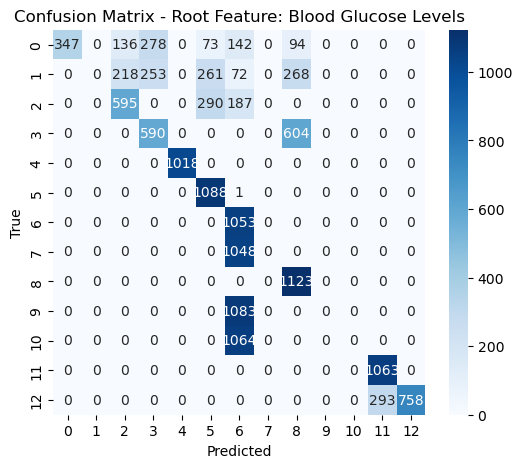

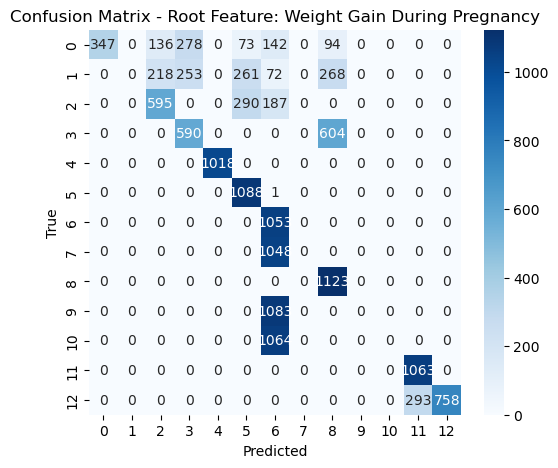

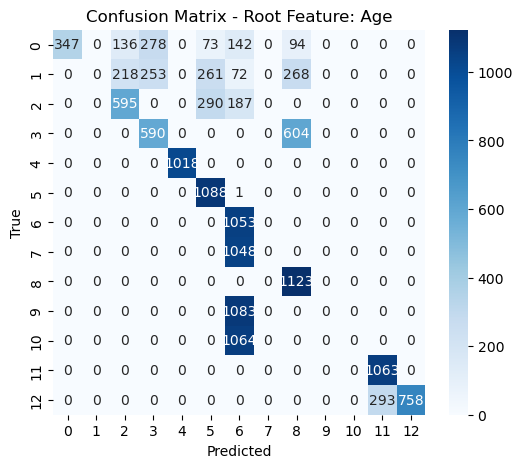

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for feature, content in trees.items():
    model = content['model']
    X_test_feat = content['X_test']
    y_pred = model.predict(X_test_feat)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - Root Feature: {feature}')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


## Step 5.6: Visualize Tree Structures

- Use `plot_tree()` to generate visual diagrams of the trained trees.
- Observe how different root features affect the entire tree structure.
- Helps in interpreting decision paths and understanding model logic.

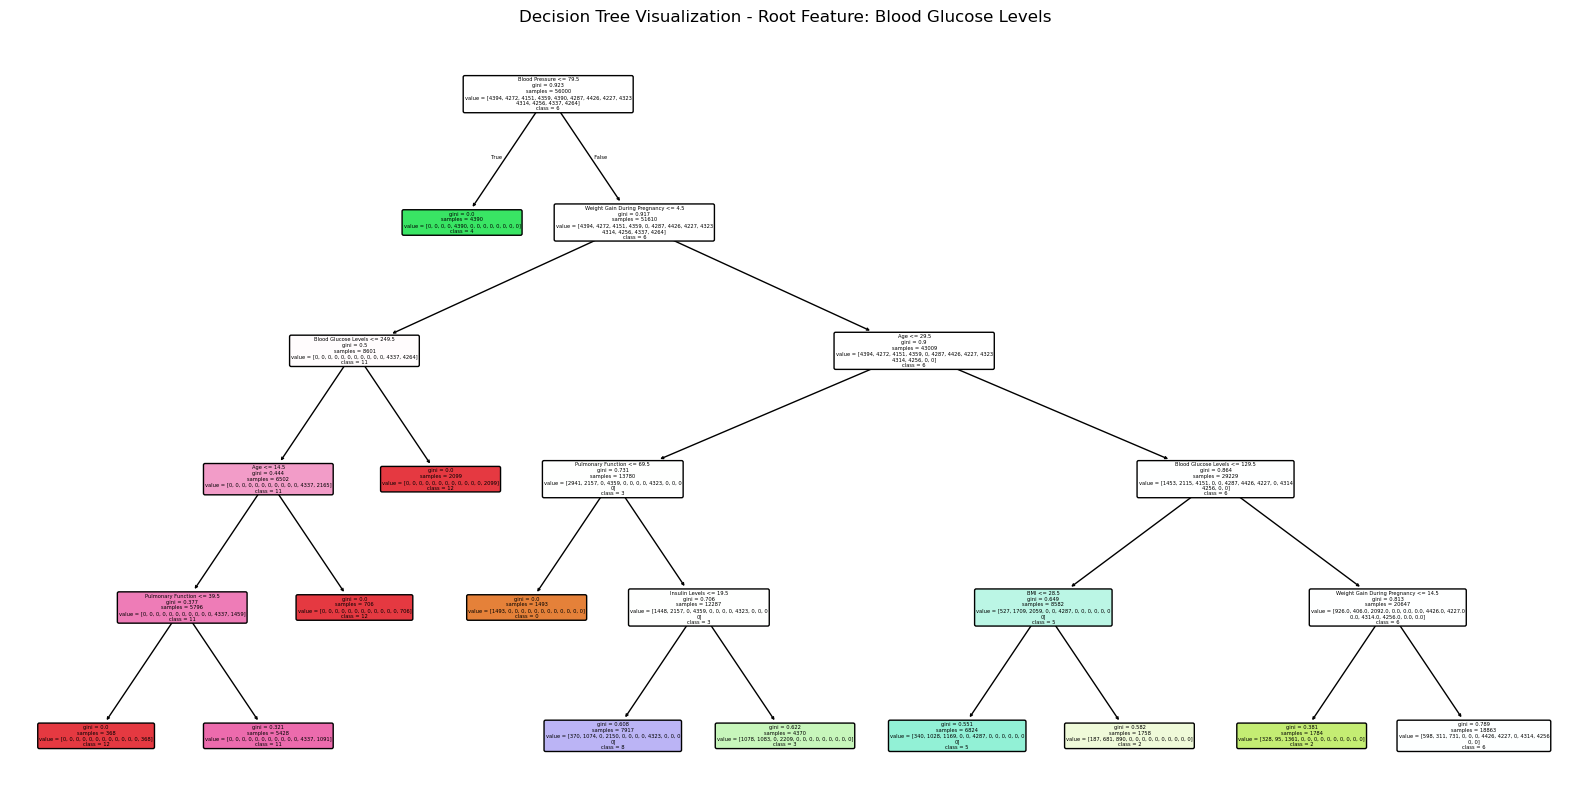

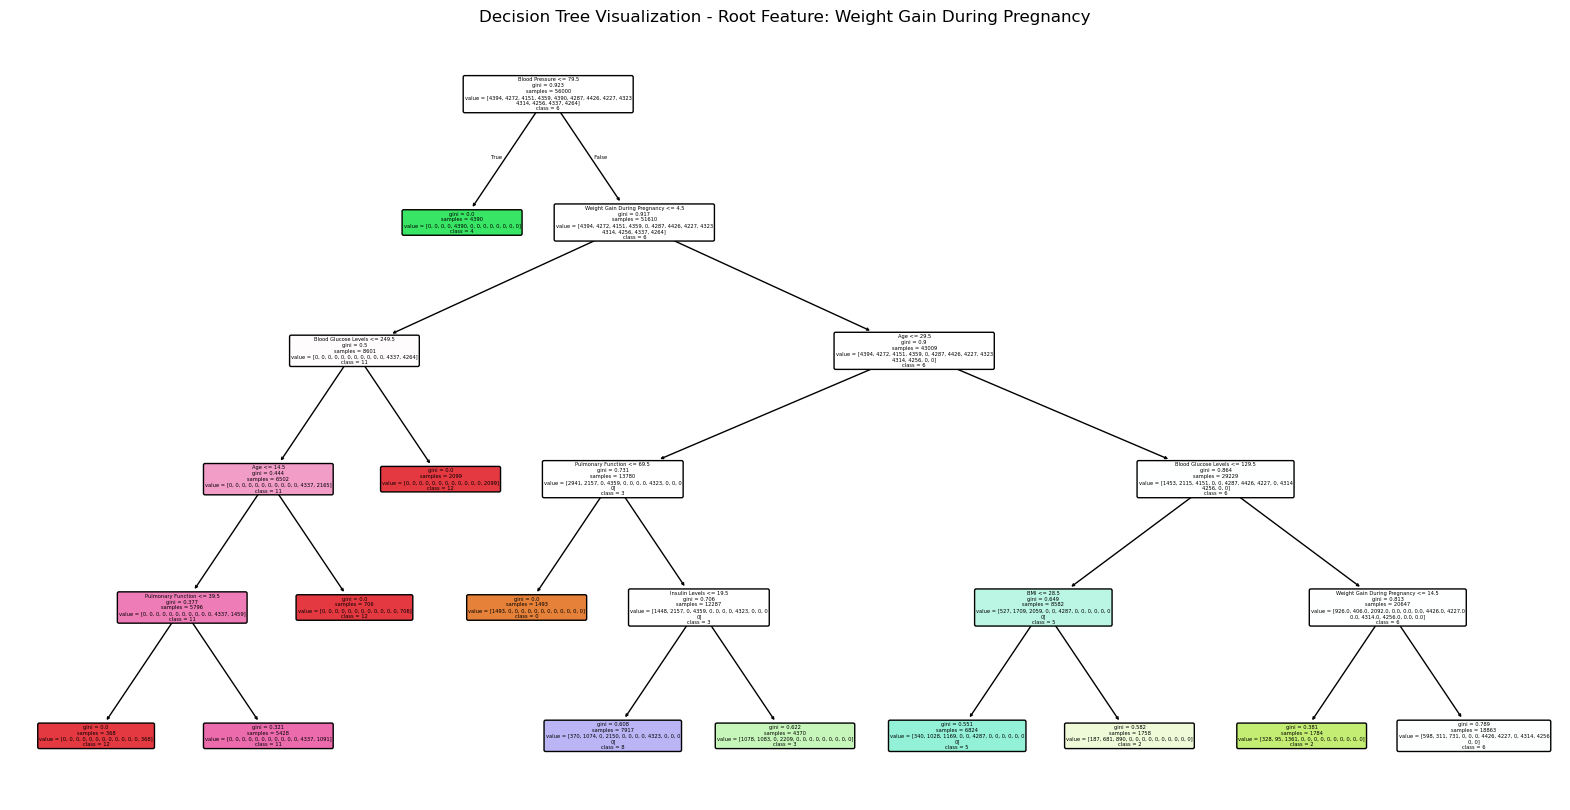

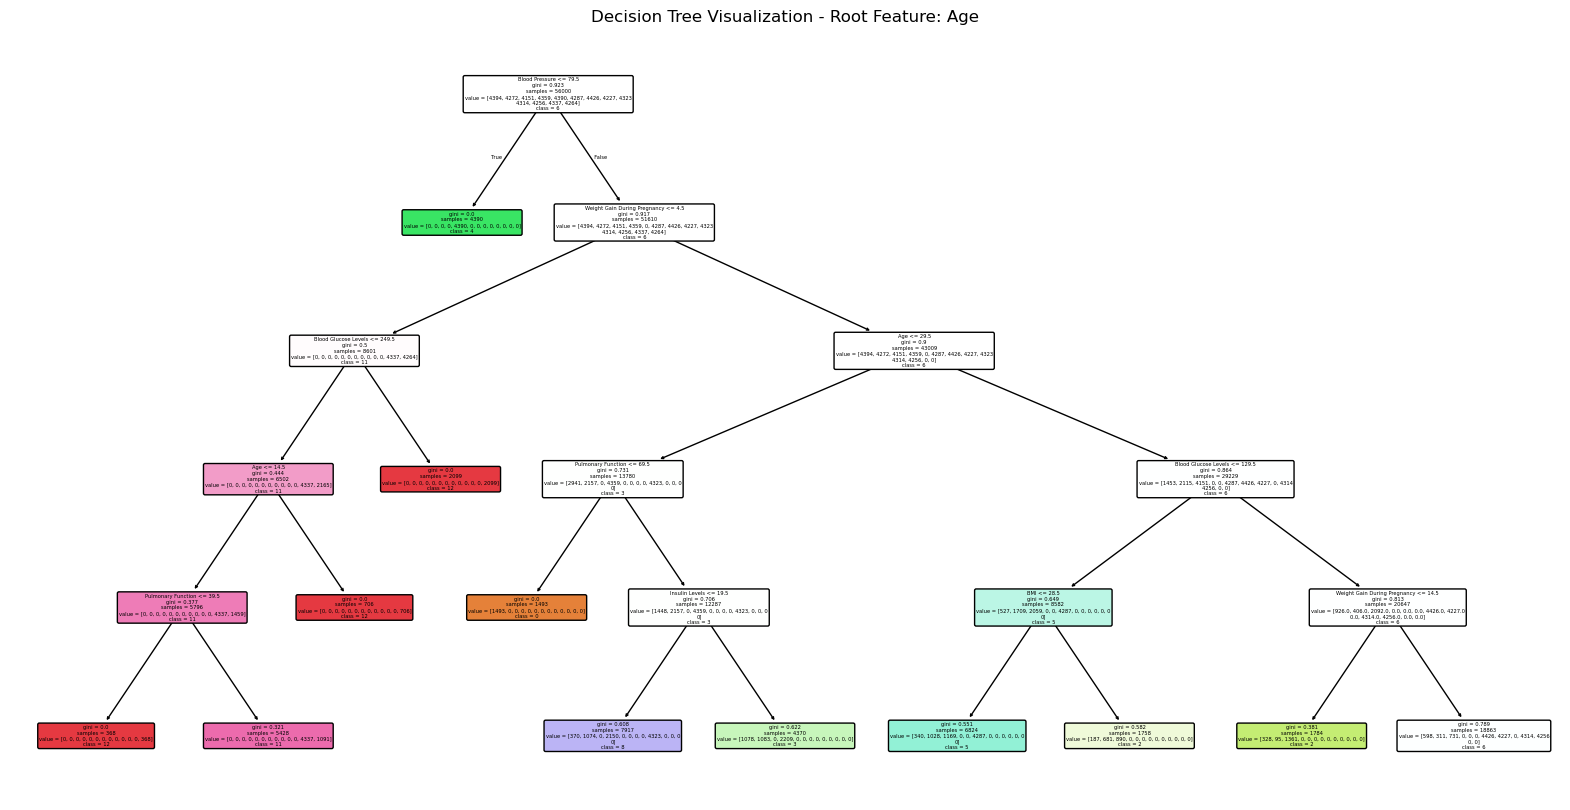

In [22]:
from sklearn.tree import plot_tree

for feature, content in trees.items():
    model = content['model']
    reordered_features = reorder_features(X_train, feature).columns.tolist()

    plt.figure(figsize=(20, 10))
    plot_tree(
        model,
        feature_names=reordered_features,
        class_names=model.classes_.astype(str),  # dynamically grab classes
        filled=True,
        rounded=True
    )
    plt.title(f"Decision Tree Visualization - Root Feature: {feature}")
    plt.show()


## Step 6: Hyperparameter Tuning for Decision Tree

After training a basic Decision Tree in Step 5, we observed suboptimal accuracy. In this step, we improve performance through **hyperparameter tuning** using `GridSearchCV`.

- **Why Tune?**  
  Decision Trees can easily overfit or underfit based on parameters like tree depth, splitting criteria, and minimum sample thresholds. Tuning helps find a balanced and more accurate model.

### Key Hyperparameters Considered:
- `criterion`: Measures the quality of a split (`gini` for Gini Impurity, `entropy` for Information Gain)
- `max_depth`: Maximum depth of the tree (limits complexity to reduce overfitting)
- `min_samples_split`: Minimum number of samples required to split an internal node
- `min_samples_leaf`: Minimum number of samples required to be at a leaf node

### Process:
1. Define a grid of hyperparameters to test.
2. Use `GridSearchCV` with 5-fold cross-validation to evaluate combinations.
3. Retrieve the best performing model based on validation accuracy.
4. Evaluate the tuned model using:
   - Accuracy
   - Confusion Matrix
   - Classification Report

This step significantly boosts performance by finding the optimal decision tree structure for our dataset.

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}

Root Feature: Genetic Markers
Accuracy: 0.8877857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92      1093
           1       0.86      0.89      0.88      1069
           2       0.97      0.90      0.93      1044
           3       0.96      0.83      0.89      1111
           4       1.00      1.00      1.00      1082
           5       0.96      1.00      0.98      1075
           6       0.82      0.74      0.78      1096
           7       0.79      0.82      0.80      1055
           8       0.84      1.00      0.91      1089
           9       0.86      0.71      0.78      1079
          10       0.81      1.00      0.89      1064
          11       0.90      0.86      0.88      1080
          12       0.87      0.90      0.88 

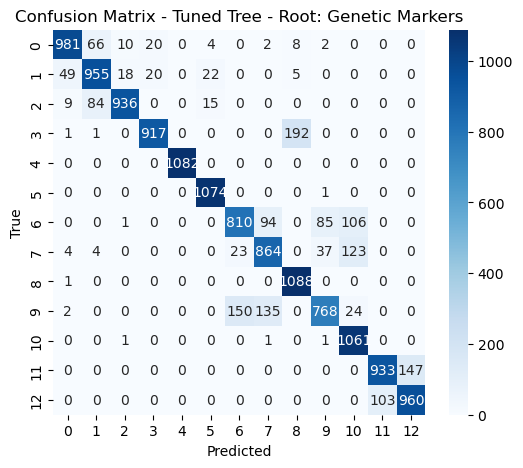


Root Feature: Autoantibodies
Accuracy: 0.8875

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92      1093
           1       0.86      0.89      0.88      1069
           2       0.97      0.90      0.93      1044
           3       0.96      0.83      0.89      1111
           4       1.00      1.00      1.00      1082
           5       0.96      1.00      0.98      1075
           6       0.82      0.74      0.78      1096
           7       0.79      0.82      0.80      1055
           8       0.84      1.00      0.91      1089
           9       0.86      0.71      0.78      1079
          10       0.81      1.00      0.89      1064
          11       0.90      0.86      0.88      1080
          12       0.87      0.90      0.88      1063

    accuracy                           0.89     14000
   macro avg       0.89      0.89      0.89     14000
weighted avg       0.89      0.89      0.89     14000



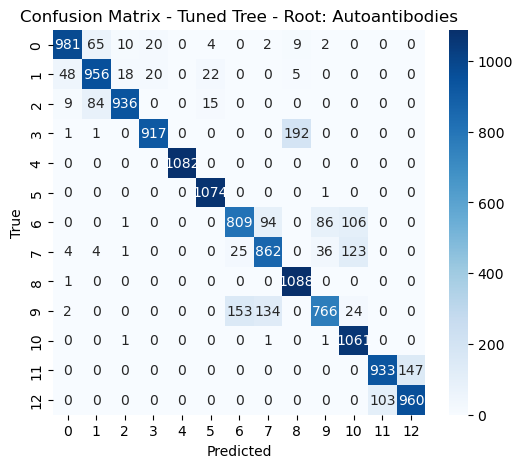


Root Feature: Family History
Accuracy: 0.8875

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92      1093
           1       0.86      0.89      0.88      1069
           2       0.97      0.90      0.93      1044
           3       0.96      0.83      0.89      1111
           4       1.00      1.00      1.00      1082
           5       0.96      1.00      0.98      1075
           6       0.82      0.74      0.78      1096
           7       0.79      0.82      0.80      1055
           8       0.84      1.00      0.91      1089
           9       0.86      0.71      0.78      1079
          10       0.81      1.00      0.89      1064
          11       0.90      0.86      0.88      1080
          12       0.87      0.90      0.88      1063

    accuracy                           0.89     14000
   macro avg       0.89      0.89      0.89     14000
weighted avg       0.89      0.89      0.89     14000



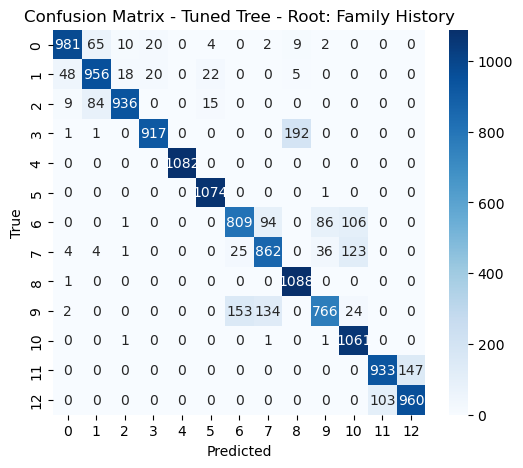

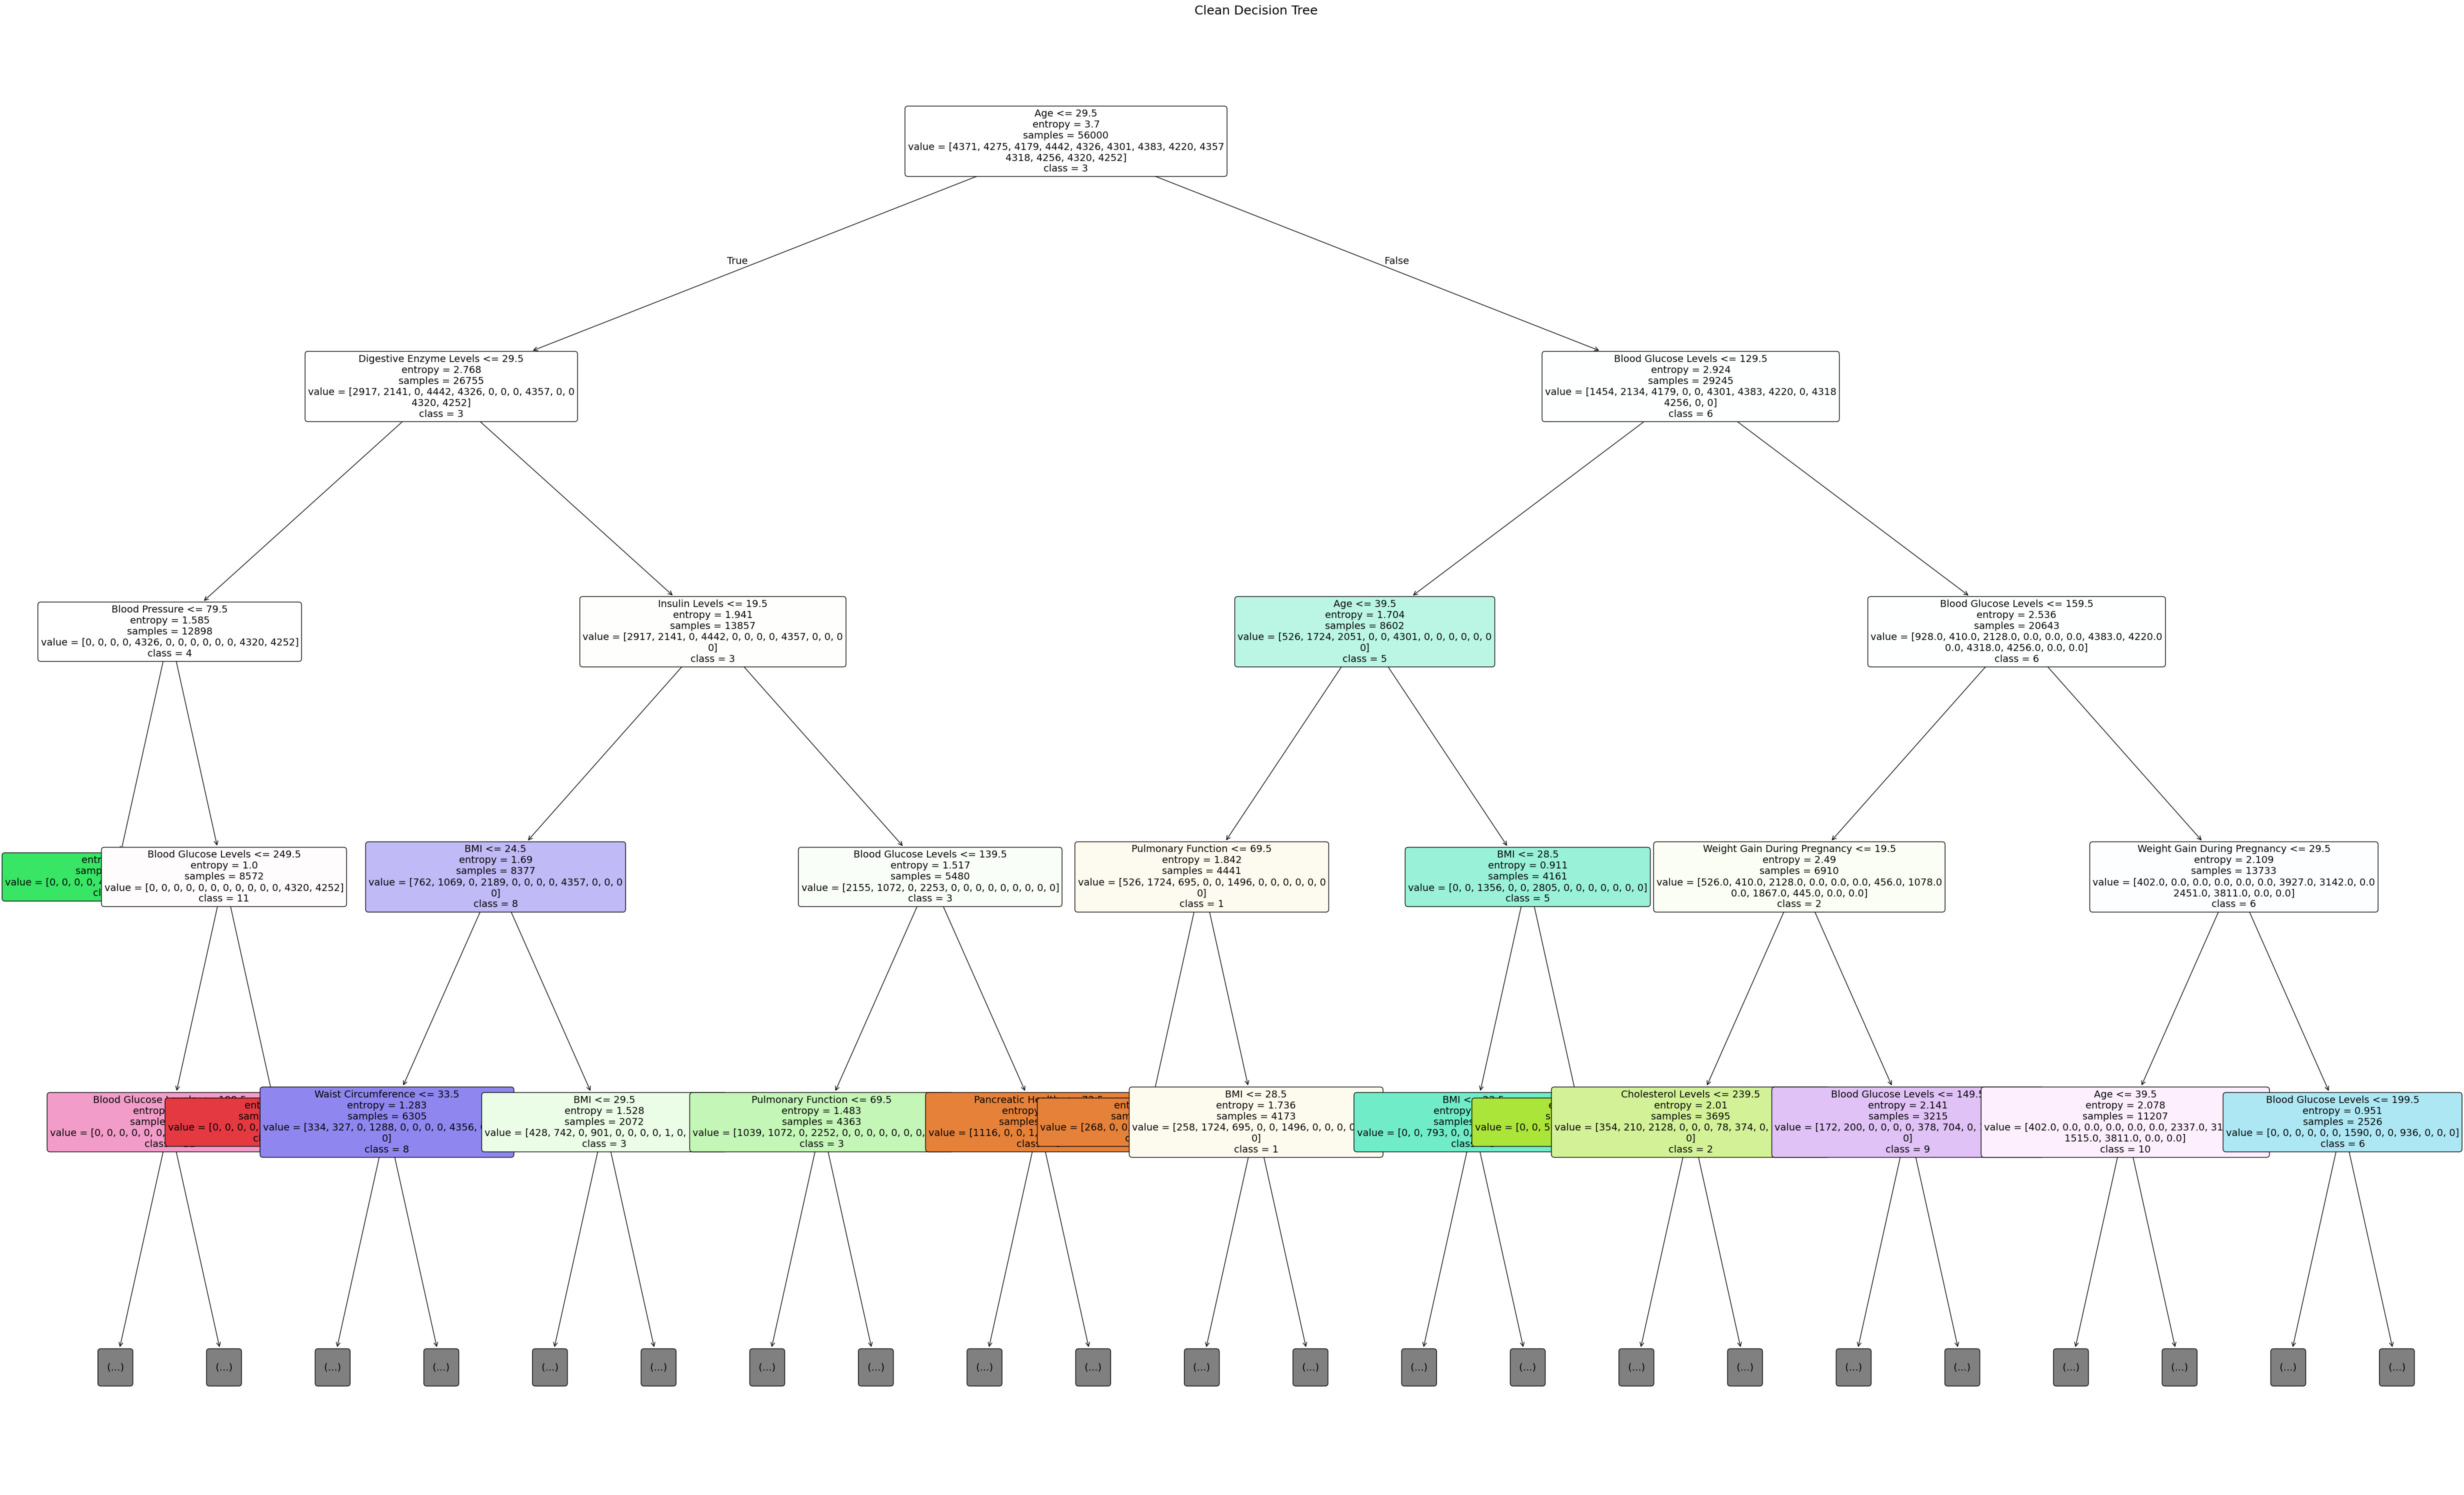

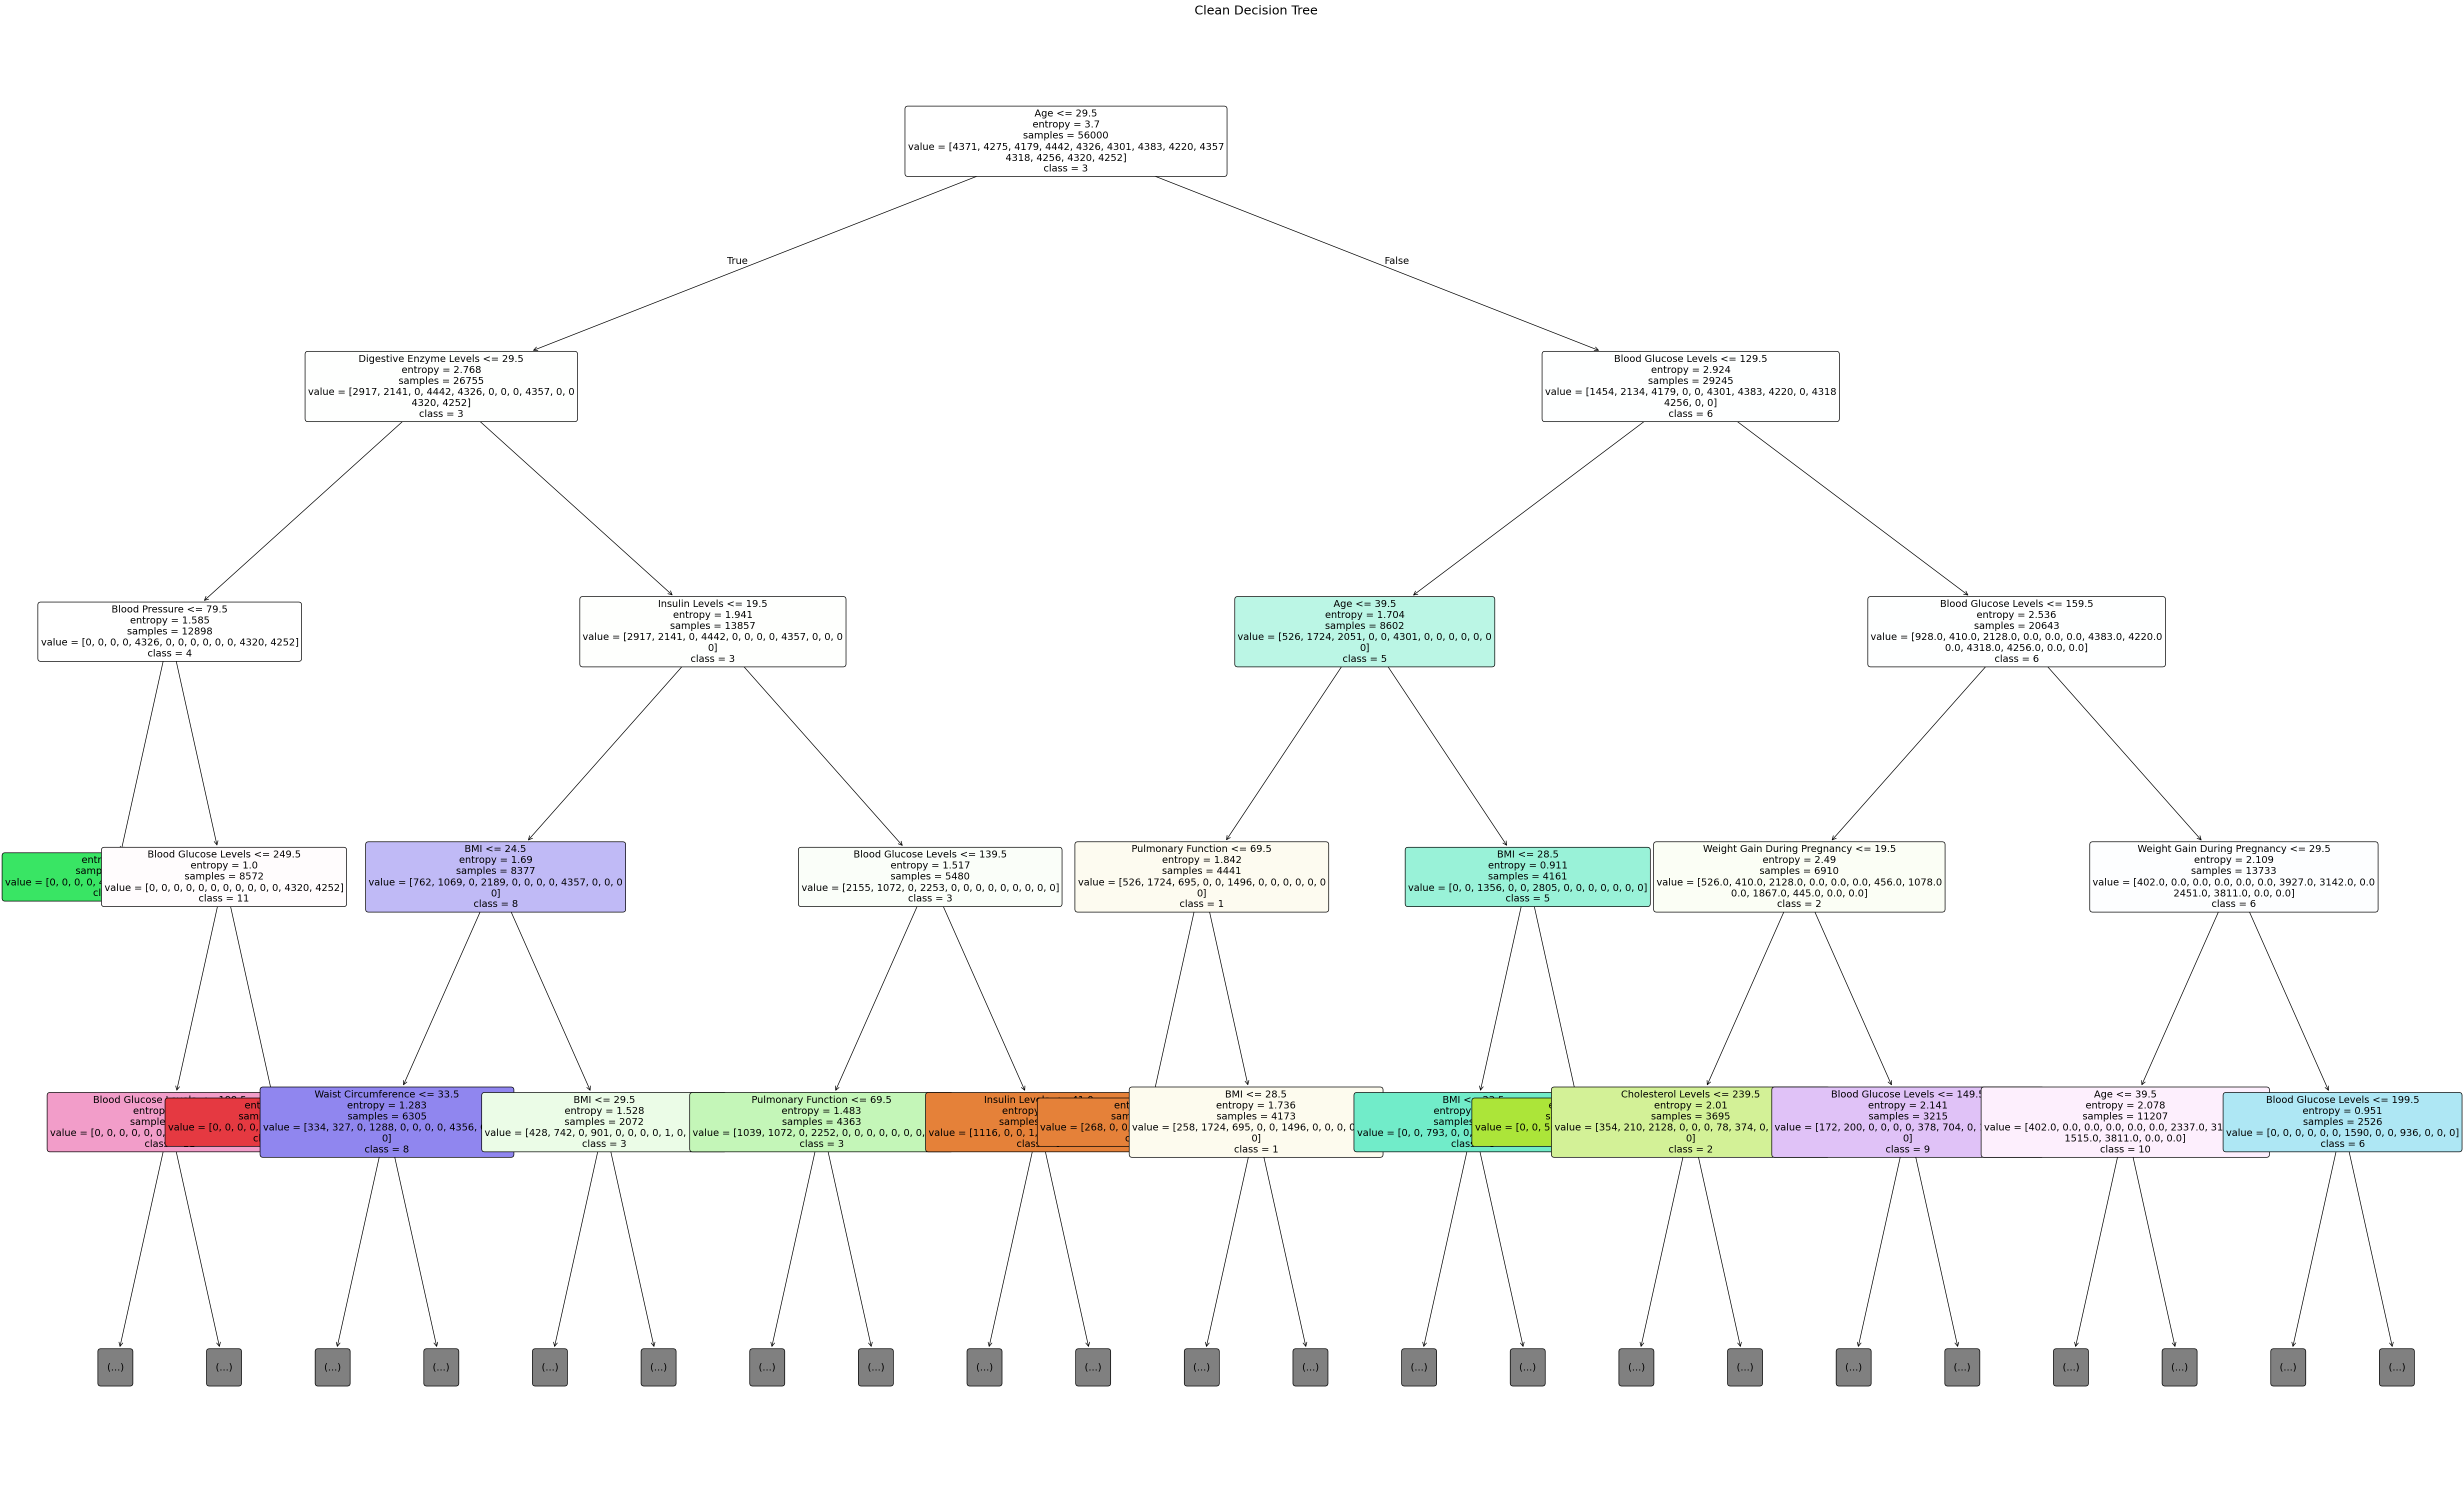

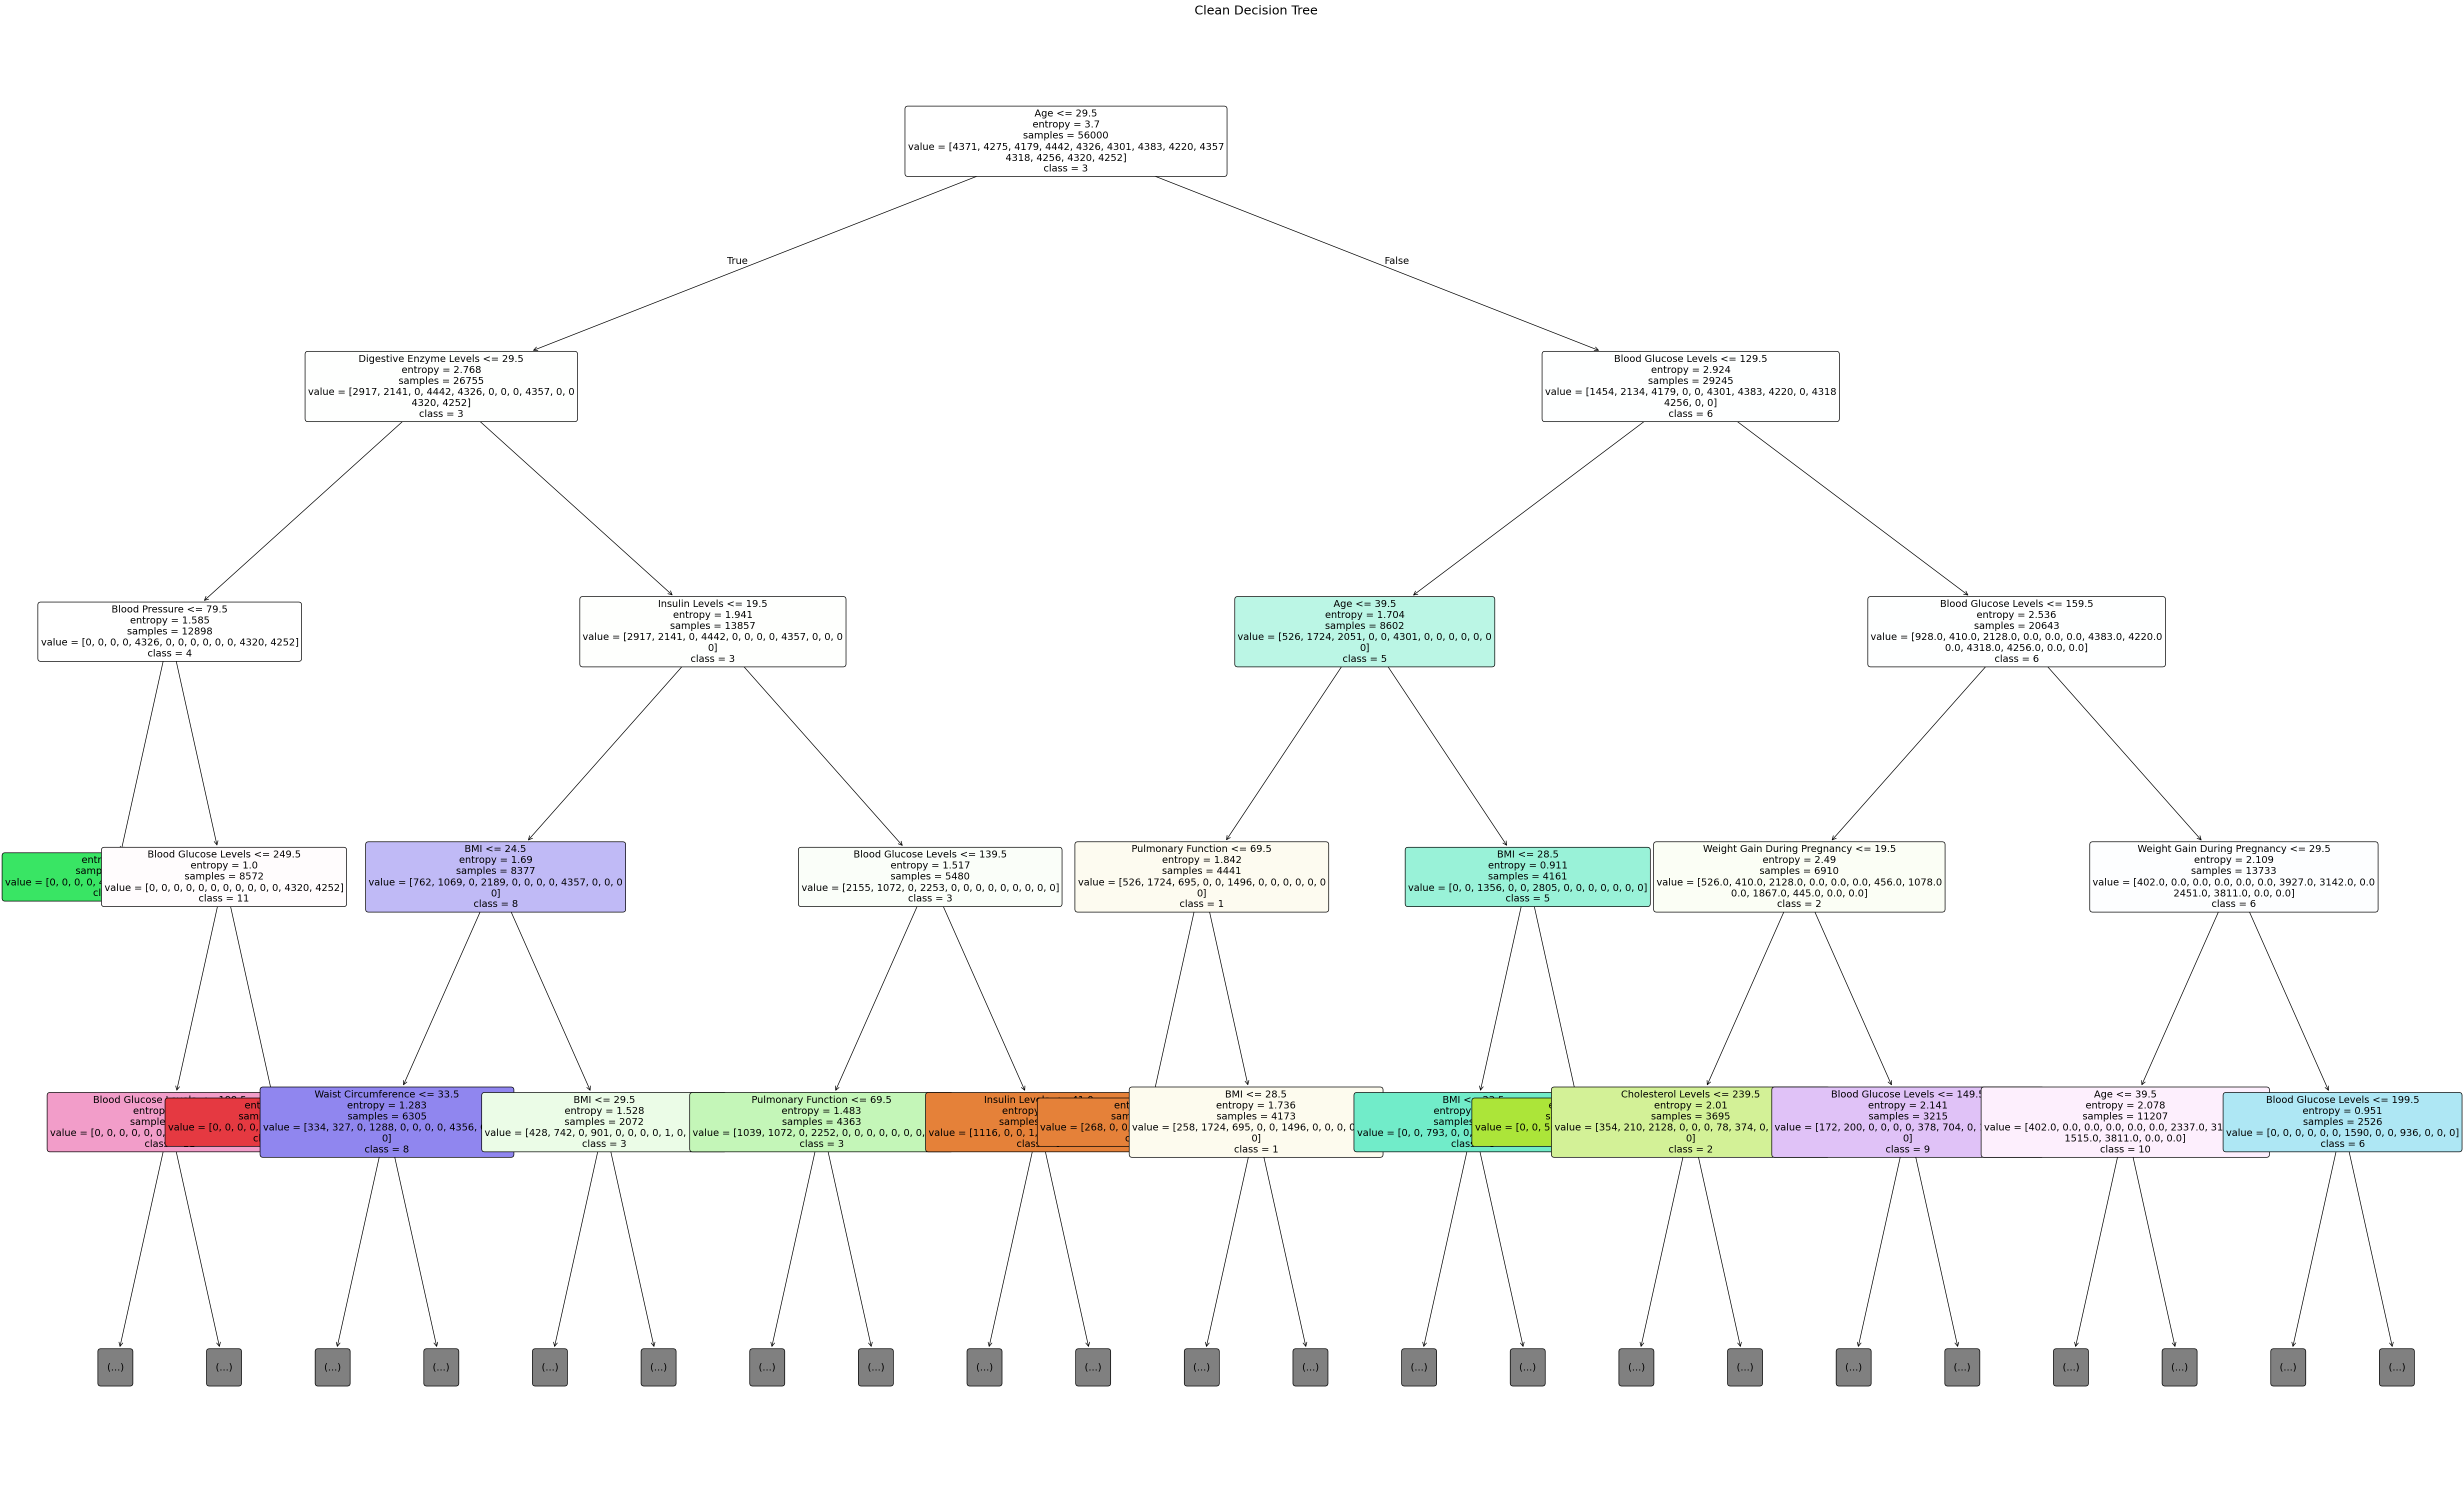

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("dt_prepared.csv")
X = df.drop("Target", axis=1)
y = df["Target"]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# GridSearchCV for best parameters
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid,
                           scoring='accuracy', cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Helper to reorder features
def reorder_features(X, root_feature):
    cols = [root_feature] + [col for col in X.columns if col != root_feature]
    return X[cols]

# Build trees with different root nodes
trees_tuned = {}
top_features = X_train.columns[:3]  # Choose any top 3 features
for root_feature in top_features:
    X_train_rooted = reorder_features(X_train, root_feature)
    X_test_rooted = reorder_features(X_test, root_feature)
    model = DecisionTreeClassifier(**best_params, random_state=42)
    model.fit(X_train_rooted, y_train)
    trees_tuned[root_feature] = {
        'model': model,
        'X_test': X_test_rooted
    }

# Evaluate each tree
for feature, content in trees_tuned.items():
    model = content['model']
    X_test_feat = content['X_test']
    y_pred = model.predict(X_test_feat)
    print(f"\nRoot Feature: {feature}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - Tuned Tree - Root: {feature}')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Visualize each tree
for feature, content in trees_tuned.items():
    model = content['model']
    reordered_features = reorder_features(X_train, feature).columns.tolist()
    plt.figure(figsize=(50, 30))  # Increase figure size massively
    plot_tree(
    model,
    feature_names=reordered_features,
    class_names=[str(cls) for cls in model.classes_],  # Dynamically fetch class names
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=14
    )

    plt.title("Clean Decision Tree", fontsize=18)
    plt.tight_layout()
    plt.savefig("tree_high_res.png", dpi=300)  # High-res output
    plt.show()

